# <center> Ridge Regression on simulated data
    
Authors: Rémi LELUC, François PORTIER

### Import Libraries

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from models import linearReg
from simus import run_ols
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
from tqdm.notebook import tqdm

### Simulate data for regression

In [35]:
# Number of samples and dimension
n_samples = 5000   # number of samples
#n_features = 20    # dimension of the problem
n_features = 100    # dimension of the problem

# Simulate data for regression
seed=0
noise=0.1
X,y = make_regression(n_samples=n_samples,
                     n_features=n_features,
                      noise=noise,random_state=seed)
y/=y.sum()

### Compute optimal $\theta^\star$

In [36]:
𝜆 = 1/n_samples          #regularization parameter
G = ((X.T)@X)/n_samples  # Gram matrix
A = G + 𝜆*np.eye(n_features)
B = ((X.T)@y)/n_samples
# compute ridge solution
ridge = np.linalg.solve(a=A ,b=B)

In [37]:
data_opt = np.sum((y-X.dot(ridge))**2)/(2*n_samples)
reg_opt = (𝜆/2) * sum(ridge**2)
loss_opt = data_opt + reg_opt
print('data_opt:',data_opt)
print('reg_opt :',reg_opt)
print(loss_opt)

data_opt: 1.3604183902735365e-11
reg_opt : 7.974013400249347e-09
7.987617584152082e-09


## Parameter simulations

- n=5,000 and d=20:

N = int(2e2); N_exp = 30; lr = 1; k0 = 4; alpha_power = 1 ; batch_size= 4; batch_hess= 4; c=1             
power =1/2; 𝜂 = 200; same=True 

- n=5,000 and d=100:

N = int(2e2); N_exp = 30; lr = 1; k0 = 4; alpha_power = 1 ; batch_size= 32; batch_hess= 32; c=0.1             
power =1/2; 𝜂 = 200; same=True 

In [38]:
N = int(2e2)    # number of passes over coordinates
N_exp = 30      # number of experiments
lr = 1          # numerator of learning rate
k0 = 4          # smoothing parameter, denominator of learning rate
alpha_power = 1 # power in the learning rate
batch_size= 32   # batch size for gradient estimates 
batch_hess= 32  # batch size for hessian estimates
c=0.1             # numerator learning rate gamma_k for C_k
power =1/2      # power of learning rate gamma_k for C_k
𝜂 = 200         # importance weights parameter
same=True       # same batch for gradient/hessian

### SGD and Polyak-averaging

In [39]:
# SGD
w_sgd,loss_sgd = run_ols(X=X,y=y,𝜆=𝜆,method='sgd',N_exp=N_exp,N=N,
                         batch_size=batch_size,batch_hess=batch_hess,lr=lr,c=c,k0=k0,
                         alpha_power=alpha_power,𝜂=None,power=None,same=None)
# Polyak-averaging SGD
w_sgd_avg,loss_sgd_avg = run_ols(X=X,y=y,𝜆=𝜆,method='sgd-avg',N_exp=N_exp,N=N,
                                 batch_size=batch_size,batch_hess=batch_hess,lr=lr,c=c,k0=k0,
                                 alpha_power=alpha_power,𝜂=None,power=None,same=None)

### Conditioned-SGD with equal and adaptive weights

In [40]:
# C-SGD equal
w_equal,loss_equal = run_ols(X=X,y=y,𝜆=𝜆,method='csgd',N_exp=N_exp,N=N,
                             batch_size=batch_size,batch_hess=batch_hess,lr=lr,c=c,k0=k0,
                             alpha_power=alpha_power,𝜂=0,power=power,same=same)

# C-SGD weighted
w_weighted,loss_weighted = run_ols(X=X,y=y,𝜆=𝜆,method='csgd',N_exp=N_exp,N=N,
                                   batch_size=batch_size,batch_hess=batch_hess,lr=lr,c=c,k0=k0,
                                   alpha_power=alpha_power,𝜂=𝜂,power=power,same=same)

### Save all results

In [44]:
#np.save('results/ridge_sgd_n{}_d{}'.format(n_samples,n_features),loss_sgd-loss_opt)
#np.save('results/ridge_sgd_avg_n{}_d{}'.format(n_samples,n_features),loss_sgd_avg-loss_opt)
#np.save('results/ridge_equal_n{}_d{}'.format(n_samples,n_features),loss_equal-loss_opt)
#np.save('results/ridge_weighted_n{}_d{}'.format(n_samples,n_features),loss_weighted-loss_opt)

### Compute means and standard deviations over runs

In [42]:
mean_sgd = np.mean(loss_sgd,axis=0)
mean_sgd_avg = np.mean(loss_sgd_avg,axis=0)
mean_equal = np.mean(loss_equal,axis=0)
mean_weighted = np.mean(loss_weighted,axis=0)

std_sgd = np.std(loss_sgd,axis=0)/2
std_sgd_avg = np.std(loss_sgd_avg,axis=0)/2
std_equal = np.std(loss_equal,axis=0)/2
std_weighted = np.std(loss_weighted,axis=0)/2

### Plot figures to check

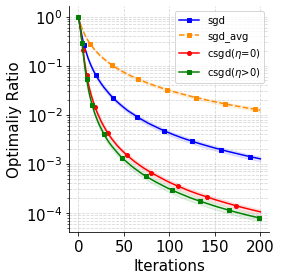

In [43]:
tab = np.arange(N+1)
fig,ax = plt.subplots(figsize=(4,4))
# SGD curves
plt.plot((mean_sgd-loss_opt)/(mean_sgd[0]-loss_opt),
         color='b',label='sgd',
         linestyle='-',marker='s',markevery=0.1,ms=4)
plt.fill_between(tab,
                 (mean_sgd-loss_opt-std_sgd)/(mean_sgd[0]-loss_opt),
                 (mean_sgd-loss_opt+std_sgd)/(mean_sgd[0]-loss_opt),
                  color='b',alpha=0.1)
# Polyak-averaging curves
plt.plot((mean_sgd_avg-loss_opt)/(mean_sgd_avg[0]-loss_opt),
         color='darkorange',label='sgd_avg',
         linestyle='--',marker='s',markevery=0.1,ms=4)
plt.fill_between(tab,
                 (mean_sgd_avg-loss_opt-std_sgd_avg)/(mean_sgd_avg[0]-loss_opt),
                 (mean_sgd_avg-loss_opt+std_sgd_avg)/(mean_sgd_avg[0]-loss_opt),
                  color='darkorange',alpha=0.1)
# C-SGD equal curves
plt.plot((mean_equal-loss_opt)/(mean_equal[0]-loss_opt),
         color='red',label=r'csgd($\eta$=0)',
         linestyle='-',marker='o',markevery=0.1,ms=4)
plt.fill_between(tab,
                 (mean_equal-loss_opt-std_equal)/(mean_equal[0]-loss_opt),
                 (mean_equal-loss_opt+std_equal)/(mean_equal[0]-loss_opt),
                  color='red',alpha=0.1)
# C-SGD weighted curves
plt.plot((mean_weighted-loss_opt)/(mean_weighted[0]-loss_opt),
         color='green',label=r'csgd($\eta$>0)',
         linestyle='-',marker='s',markevery=0.1,ms=4)
plt.fill_between(tab,
                 (mean_weighted-loss_opt-std_weighted)/(mean_weighted[0]-loss_opt),
                 (mean_weighted-loss_opt+std_weighted)/(mean_weighted[0]-loss_opt),
                  color='green',alpha=0.1)
# Graphics and Layout
plt.yscale('log')
plt.ylabel(r'Optimaliy Ratio',fontsize=15)
plt.xlabel('Iterations',fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.legend(loc='upper right',fontsize=10)
plt.grid(linestyle='--',which='both',alpha=0.5)
plt.tight_layout()
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Uncomment to save figure
#plt.savefig('ridge_n5000_d20.pdf',bbox_inches='tight',transparent=True,pad_inches=0)
#plt.savefig('ridge_n5000_d100.pdf',bbox_inches='tight',transparent=True,pad_inches=0)
plt.show()